mpg: Aracın yakıt tüketimini gösterir, 1 galon benzinle kaç mil gidebildiğini belirtir.

cylinders: Motorun sahip olduğu silindir sayısını belirtir.

displacement: Motorun hacmini belirtir (inç küp cinsinden).

horsepower: Motorun beygir gücünü gösterir.

weight: Aracın ağırlığını pound cinsinden belirtir.

acceleration: Aracın 0'dan 60 mil/saat'e ulaşma süresini (saniye cinsinden) gösterir.

model_year: Aracın model yılıdır, zamanla ilişkili sayısal bir değişkendir.

origin: Aracın üretildiği bölgeyi belirtir (1 = ABD, 2 = Avrupa, 3 = Japonya).

car_name: Aracın marka ve model adını belirtir, genellikle analizde kullanılmaz.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!pip install ucimlrepo


In [3]:
from ucimlrepo import fetch_ucirepo
auto_mpg = fetch_ucirepo(id=9)
X = auto_mpg.data.features # X featureların yer aldığı değişken
y = auto_mpg.data.targets #y target değişkenimiz olan mpga'nın yer aldığı değişken

In [4]:
print(auto_mpg.variables)

           name     role         type demographic description units  \
0  displacement  Feature   Continuous        None        None  None   
1           mpg   Target   Continuous        None        None  None   
2     cylinders  Feature      Integer        None        None  None   
3    horsepower  Feature   Continuous        None        None  None   
4        weight  Feature   Continuous        None        None  None   
5  acceleration  Feature   Continuous        None        None  None   
6    model_year  Feature      Integer        None        None  None   
7        origin  Feature      Integer        None        None  None   
8      car_name       ID  Categorical        None        None  None   

  missing_values  
0             no  
1             no  
2             no  
3            yes  
4             no  
5             no  
6             no  
7             no  
8             no  


In [5]:
print(type(auto_mpg))

<class 'ucimlrepo.dotdict.dotdict'>


In [6]:
X.head() #features

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


In [7]:
y.head() #label

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [8]:
display(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


None

In [9]:
display(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     398 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


None

In [10]:
X.shape

(398, 7)

In [11]:
y.shape

(398, 1)

In [12]:
X.dtypes

,0
displacement,float64
cylinders,int64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,int64


In [13]:
y.dtypes

,0
mpg,float64


In [14]:
X.isnull().sum()

,0
displacement,0
cylinders,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0


In [15]:
X['horsepower'] = X['horsepower'].fillna(X['horsepower'].median()) # eksik değeri medyanla doldurduk

<ipython-input-15-6d045dc14af6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['horsepower'] = X['horsepower'].fillna(X['horsepower'].median()) # eksik değeri medyanla doldurduk


In [16]:
y.isnull().sum()

,0
mpg,0


In [17]:
X.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,5.454774,104.304020,2970.424623,15.568090,76.010050,1.572864
std,104.269838,1.701004,38.222625,846.841774,2.757689,3.697627,0.802055
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,104.250000,4.000000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,262.000000,8.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [18]:
y.describe()

,mpg
count,398.000000
mean,23.514573
std,7.815984
min,9.000000
25%,17.500000
50%,23.000000
75%,29.000000
max,46.600000


In [19]:
X = pd.get_dummies(X, columns=["origin"],  drop_first=True) # origini encode ettik çünkü origin aslında ülkeleri belirtiyor. Sayılarda büyüklük küçüklük ilişkisi olmamalı

In [20]:
X.head(20)  #origin encode edilmiş

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin_2,origin_3
0,307.0,8,130.0,3504,12.0,70,False,False
1,350.0,8,165.0,3693,11.5,70,False,False
2,318.0,8,150.0,3436,11.0,70,False,False
3,304.0,8,150.0,3433,12.0,70,False,False
4,302.0,8,140.0,3449,10.5,70,False,False
5,429.0,8,198.0,4341,10.0,70,False,False
6,454.0,8,220.0,4354,9.0,70,False,False
7,440.0,8,215.0,4312,8.5,70,False,False
8,455.0,8,225.0,4425,10.0,70,False,False
9,390.0,8,190.0,3850,8.5,70,False,False


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #standardizasyondan önce test ve eğitim olarak ayırıyoruz çünkü data leak i önlüyoruz.

In [22]:
from sklearn.preprocessing import StandardScaler
sürekli_değişkenler = ["displacement", "horsepower", "weight", "acceleration"]
scaler = StandardScaler()
X_train[sürekli_değişkenler] = scaler.fit_transform(X_train[sürekli_değişkenler])
X_test[sürekli_değişkenler] = scaler.transform(X_test[sürekli_değişkenler])

In [23]:
print(X_train[sürekli_değişkenler].isnull().sum())

displacement    0
horsepower      0
weight          0
acceleration    0
dtype: int64


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model oluşturma
lr_model = LinearRegression()

# Modeli eğitme
lr_model.fit(X_train[sürekli_değişkenler], y_train)

# Test seti ile tahmin yapma
y_pred = lr_model.predict(X_test[sürekli_değişkenler])

# Performans değerlendirme
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Sonuçları yazdıralım
print(f"MAE: {mae}")  #	Ortalama mutlak hata düşük  iyi bir şey
print(f"MSE: {mse}")  #	Hataların karesel ortalaması
print(f"R²: {r2}")    #	Açıklanan varyans yüzdesi

MAE: 3.1313013150390168
MSE: 14.81641792818981
R²: 0.7244300181525432


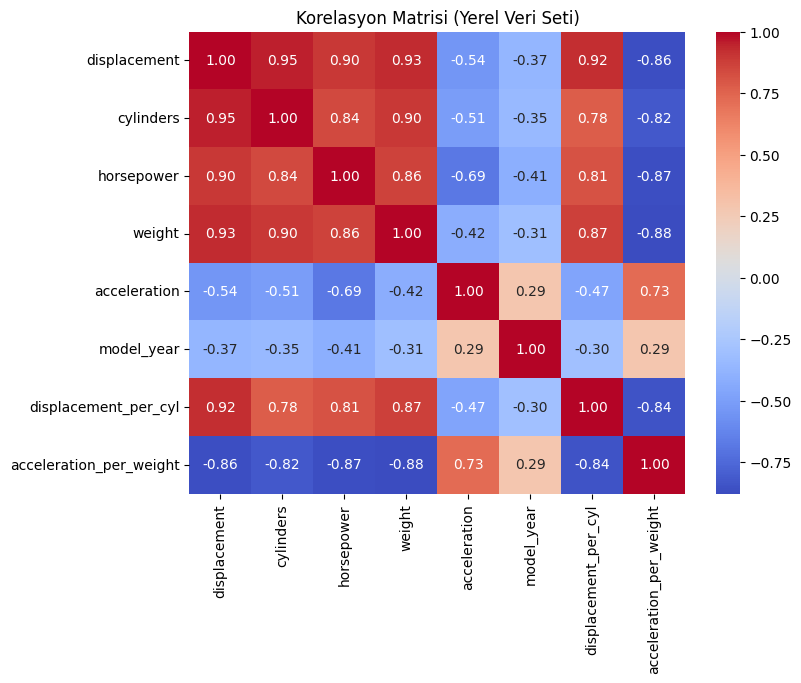

In [35]:
df_local = pd.DataFrame(X.select_dtypes(include=["int64", "float64"]))
 #Korelasyon matrisi
correlation_matrix_local = df_local.corr()

# Korelasyon matrisi görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_local, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasyon Matrisi (Yerel Veri Seti)")
plt.show()



In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data_local = pd.DataFrame()
vif_data_local['Feature'] = df_local.columns
vif_data_local['VIF'] = [variance_inflation_factor(df_local.values, i) for i in range(df_local.shape[1])]
print("Orijinal VIF Değerleri:")
print(vif_data_local)


Orijinal VIF Değerleri:
        Feature         VIF
0  displacement   86.732437
1     cylinders  114.987026
2    horsepower   58.787856
3        weight  135.199874
4  acceleration   68.062820
5    model_year  108.643443


displacement,cylindir, weight, horesepower'in vif değeri ve korelasyonu çok yüksek multikolinerlik var en az birini çıkartalım

In [27]:
import numpy as np
# Özellik mühendisliği

X["displacement_per_cyl"] = X["displacement"] / X["cylinders"]
X["acceleration_per_weight"] = X["acceleration"] / X["weight"]

df_local = pd.DataFrame(X.select_dtypes(include=[np.number]))
from statsmodels.stats.outliers_influence import variance_inflation_factor
df_dropped = df_local.drop(columns=['horsepower','weight','displacement','acceleration','model_year','cylinders'])

# VIF değerlerini yeniden hesaplama
vif_data_dropped = pd.DataFrame()
vif_data_dropped['Feature'] = df_dropped.columns
vif_data_dropped['VIF'] = [variance_inflation_factor(df_dropped.values, i) for i in range(df_dropped.shape[1])]
print("horsepower ve weight Çıkarıldıktan Sonra VIF Değerleri:")
print(vif_data_dropped)


horsepower ve weight Çıkarıldıktan Sonra VIF Değerleri:
                   Feature       VIF
0     displacement_per_cyl  3.306939
1  acceleration_per_weight  3.306939


 model year'ı ne yaparsam yapayım vif değerini çok arttırdığından çıkartmak zorunda kaldım. ayrıca yüksek korelasyon içerenleri de çıkarttık. böylece vifi düşürmüş olduk. Özellik mühendisliğinden yararlanarak da vifi düşürecek r^2 yi arttıracak yeni değerler ekledik



In [28]:
y.isnull().sum()

,0
mpg,0


In [29]:
from sklearn.linear_model import Ridge  #ridge, özelliklerin hedef değişken üzerindeki etkisini tahmin eder.
X_new = df_dropped  # df_dropped Ridge için kullanacağımız X

# 1. Eğitim ve test verisini ayır
X_train, X_test, y_train, y_test = train_test_split(df_dropped, y, test_size=0.2, random_state=42)

# 2. Veriyi ölçekle
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Ridge modelini oluştur ve eğit
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# 4. Tahmin yap
y_pred = ridge_model.predict(X_test_scaled)

# 5. Katsayıları yazdır
ridge_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ridge_model.coef_
})
print("Ridge Regresyon Katsayıları:")
print(ridge_coefficients)


Ridge Regresyon Katsayıları:
                   Feature  Coefficient
0     displacement_per_cyl    -2.866111
1  acceleration_per_weight     3.829289


Ridge modeline göre, silindir başına düşen motor hacmi arttıkça yakıt tüketimi artmakta (MPG düşmekte),
ağırlığa göre hızlanma arttıkça ise araç daha verimli olmaktadır (MPG yükselmekte).
Katsayıların yönü ve büyüklüğü modelin gerçek dünya ile tutarlı tahminler yaptığını göstermektedi

In [30]:
# Performans değerlendirme

mae1 = mean_absolute_error(y_test, y_pred)
mse1 = mean_squared_error(y_test, y_pred)
r21 = r2_score(y_test, y_pred)

# Sonuçları yazdıralım
print(f"MAE: {mae1}")
print(f"MSE: {mse1}")
print(f"R²: {r21}")

MAE: 3.1523509857829555
MSE: 15.710005303302959
R²: 0.7078102212534196


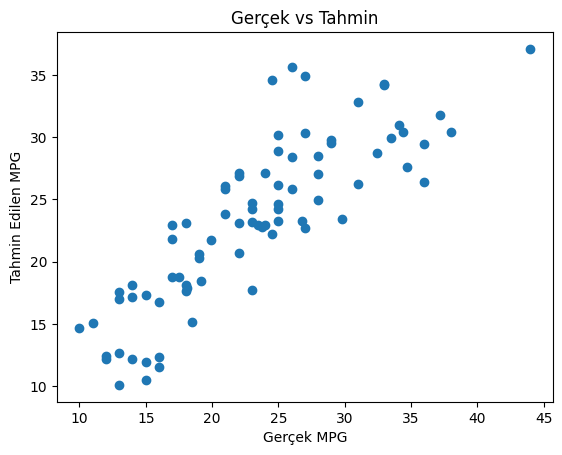

In [31]:
plt.scatter(y_test, y_pred)
plt.xlabel("Gerçek MPG")
plt.ylabel("Tahmin Edilen MPG")
plt.title("Gerçek vs Tahmin")
plt.show()

model tahminleri gerçek değere yakın gözüküyor.


In [32]:
print(vif_data_dropped)

                   Feature       VIF
0     displacement_per_cyl  3.306939
1  acceleration_per_weight  3.306939


In [33]:
from joblib import dump

# Modeli kaydet
dump(lr_model,'/content/drive/MyDrive/7.hafta/mpg.joblib')

print("Model başarıyla kaydedildi!")


Model başarıyla kaydedildi!


## bu çalışmada, mpg yi label alarak modelin başarısına yönelik tahmin yapmaya çalıştık. bu tahminlemeyi yaparken, mae mse ve r^2 değerlerine baktık. Ayrıca odelin genel güvenilirliği ve yorumlanabilirliğini ölçmek için vif ve korelasyon analizi yaptık. yüksek vif ve yüksek korelasyon olan değerleri azaltmak için özellik mühendisliği kullanarak yeni veriler ekleyip yüksek korelasyondaki verileri çıkarttık. Daha sonra ridge kullanarak multikolinerliği cezalandırdık. Bunlar da bize daha tutarlı bir tahmin yeteneği sundu.
